# LIBRARY

In [ ]:
import gzip
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score
import warnings
import gzip
import pickle
import ast
 
import numpy as np
import pandas as pd
from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import cdist_dtw
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN
warnings.filterwarnings('ignore')

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PREPARATION

## LOAD DATASET

In [ ]:
MOTIFS_CSV   = "../1.DATASET/motifs_discords.csv"
DATASET_PATH = "../1.DATASET/CMI_timeseries_personalized.pkl.gz"
CHANNELS     = ["X", "Y", "Z", "enmo", "anglez", "light"]
W            = 17
COLS_TO_DROP = ["battery_voltage", "timestamp", "quarter",
                "relative_date_PCIAT", "non-wear_flag", "weekday"]
 
# Set to True to also include discord windows in the feature vector
# Recommendation: start with False — motifs are more stable and interpretable
USE_DISCORDS = False

In [3]:
with gzip.open(DATASET_PATH, "rb") as f:
    CMI = pickle.load(f)

data_clean = [df.drop(columns=COLS_TO_DROP, errors="ignore") for df in CMI]
print(f"  {len(data_clean)} subjects loaded")


  4307 subjects loaded


## NORMALIZATION

In [4]:
signals = ["X", "Y", "Z", "enmo", "anglez", "light"]

In [5]:
def fit_global_scalers(df_list, signals):
    """Fit one RobustScaler per signal using TRAIN data only."""
    global_scalers = {}
    print("Fitting global scalers on train data...")
    for signal in signals:
        all_values = []
        for df in df_list:
            if signal not in df.columns:
                continue
            y = df[signal].values
            if np.std(y) < 0.0001 or np.ptp(y) == 0:
                continue
            all_values.append(y)
        if not all_values:
            continue
        population = np.concatenate(all_values).reshape(-1, 1)
        q25, q75   = np.percentile(population, [25, 75])
        iqr        = q75 - q25
        signal_std = np.std(population)
        if iqr > 1e-4:
            scaler = RobustScaler()
            scaler.fit(population)
            global_scalers[signal] = ("robust", scaler)
            print(f"  {signal:<18} → RobustScaler   (IQR={iqr:.4f})")
        elif signal_std > 1e-6:
            global_scalers[signal] = ("std_fallback", np.median(population), signal_std)
            print(f"  {signal:<18} → Std fallback   (IQR too small)")
        else:
            global_scalers[signal] = ("zero", None)
            print(f"  {signal:<18} → Zeroed")
    return global_scalers


In [6]:
def apply_global_scalers(df_list, global_scalers):
    """Apply pre-fitted scalers to a list of DataFrames."""
    scaled_list = []
    for df in df_list:
        target_df = df.copy()
        for signal, scaler_info in global_scalers.items():
            if signal not in target_df.columns:
                continue
            y    = target_df[signal].values.copy()
            kind = scaler_info[0]
            if kind == "robust":
                _, scaler = scaler_info
                y_scaled  = scaler.transform(y.reshape(-1, 1)).flatten()
            elif kind == "std_fallback":
                _, median, std = scaler_info
                y_scaled  = (y - median) / std
            else:
                y_scaled  = np.zeros_like(y)
            target_df[signal] = y_scaled
        scaled_list.append(target_df)
    return scaled_list


In [7]:
global_scalers = fit_global_scalers(data_clean, signals)

all_scaled = apply_global_scalers(
    data_clean,
    global_scalers
)

Fitting global scalers on train data...
  X                  → RobustScaler   (IQR=0.8341)
  Y                  → RobustScaler   (IQR=0.4156)
  Z                  → RobustScaler   (IQR=0.4314)
  enmo               → RobustScaler   (IQR=0.0454)
  anglez             → RobustScaler   (IQR=5.6440)
  light              → RobustScaler   (IQR=1.8208)


## LOAD MOTIF DATASET

In [8]:
print("Loading motifs CSV …")
motifs_df = pd.read_csv(MOTIFS_CSV)

# Parse stringified lists safely
for col in motifs_df.columns:
    if col != "sample_index":
        motifs_df[col] = motifs_df[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )

Loading motifs CSV …


In [9]:
motifs_df

,sample_index,X_motifs,X_discords,Y_motifs,Y_discords,Z_motifs,Z_discords,enmo_motifs,enmo_discords,anglez_motifs,anglez_discords,light_motifs,light_discords
0,0,"[34, 72, 67, 163, 118, 117]","[7, 12, 109]","[44, 190, 164, 182, 166, 22]","[146, 147, 115]","[67, 144, 146, 69, 66, 143]","[171, 47, 131]","[2, 69, 70, 3, 4, 71]","[138, 137, 111]","[1, 76, 71, 21, 184, 148]","[132, 134, 47]","[115, 133, 116, 150, 154, 13]","[88, 98, 24]"
1,1,"[2, 106, 15, 189, 187, 13]","[72, 71, 96]","[0, 49, 48, 44, 137, 46]","[156, 163, 6]","[100, 186, 122, 18, 121, 17]","[137, 140, 117]","[124, 189, 140, 111, 110, 139]","[100, 99, 101]","[123, 160, 159, 122, 120, 79]","[104, 117, 135]","[24, 30, 28, 23, 29, 8]","[77, 86, 81]"
2,2,"[114, 158, 157, 113, 10, 156]","[190, 26, 87]","[5, 71, 123, 16, 9, 97]","[26, 180, 52]","[31, 127, 32, 128, 129, 33]","[39, 177, 176]","[97, 114, 113, 96, 107, 150]","[62, 131, 140]","[79, 153, 129, 125, 50, 115]","[11, 10, 64]","[0, 20, 22, 14, 13, 17]","[80, 81, 79]"
3,3,"[26, 124, 55, 148, 127, 54]","[11, 12, 118]","[52, 79, 69, 103, 24, 187]","[60, 137, 33]","[83, 162, 163, 84, 47, 181]","[186, 95, 67]","[0, 56, 41, 82, 55, 148]","[115, 114, 112]","[1, 53, 54, 2, 23, 44]","[60, 67, 95]","[5, 27, 31, 7, 10, 20]","[102, 177, 178]"
4,4,"[13, 67, 15, 7, 68, 14]","[46, 47, 84]","[12, 78, 45, 18, 44, 17]","[175, 148, 121]","[175, 187, 6, 25, 177, 189]","[34, 111, 90]","[54, 73, 72, 53, 77, 131]","[175, 86, 38]","[175, 187, 22, 85, 28, 169]","[140, 91, 42]","[0, 1, 2, 3, 4, 5]","[161, 93, 61]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4302,4302,"[97, 70, 36, 179, 71, 98]","[127, 128, 129]","[38, 86, 85, 181, 182, 37]","[111, 42, 21]","[175, 190, 189, 188, 187, 186]","[47, 46, 48]","[162, 166, 164, 160, 165, 161]","[54, 55, 53]","[116, 112, 189, 188, 187, 186]","[45, 46, 44]","[0, 1, 2, 3, 4, 5]","[190, 189, 188]"
4303,4303,"[20, 188, 189, 21, 22, 190]","[96, 163, 165]","[0, 1, 2, 3, 4, 5]","[58, 177, 183]","[114, 152, 81, 62, 137, 68]","[185, 9, 132]","[0, 1, 2, 3, 4, 5]","[101, 102, 181]","[60, 189, 135, 61, 51, 155]","[70, 71, 69]","[0, 1, 2, 3, 4, 5]","[107, 106, 170]"
4304,4304,"[120, 121, 122, 123, 124, 102]","[51, 78, 77]","[120, 121, 122, 123, 124, 102]","[28, 30, 27]","[93, 148, 149, 94, 51, 99]","[190, 18, 17]","[102, 103, 101, 108, 107, 106]","[99, 98, 36]","[26, 74, 17, 13, 103, 55]","[171, 51, 157]","[0, 1, 2, 3, 4, 5]","[190, 189, 188]"
4305,4305,"[0, 1, 2, 3, 4, 5]","[58, 59, 22]","[126, 78, 73, 121, 127, 79]","[65, 6, 8]","[161, 178, 122, 74, 176, 154]","[84, 0, 1]","[0, 1, 2, 3, 4, 5]","[98, 75, 97]","[160, 155, 159, 172, 121, 73]","[1, 2, 0]","[20, 176, 175, 19, 18, 174]","[26, 116, 117]"


## SIGNAL RETRIEVAL

In [10]:
# For every subject, for every channel, pull the raw windows
# at each motif start index  →  store as fixed-length vectors

In [ ]:
def extract_windows(ts: np.ndarray, indices: list[int], w: int) -> list[np.ndarray]:
    """Return list of length-w windows; skip any that go out of bounds."""
    windows = []
    for idx in indices:
        if idx + w <= len(ts):
            windows.append(ts[idx: idx + w])
    return windows

In [ ]:
def motif_medoid(windows: list) -> np.ndarray:
    """Restituisce la finestra più centrale (medoid) tra quelle disponibili."""
    if len(windows) == 0:
        return None
    if len(windows) == 1:
        return windows[0]
    X = np.vstack(windows)                    # (n_motifs, W)
    D = cdist(X, X, metric="euclidean")
    medoid_idx = np.argmin(D.sum(axis=1))
    return X[medoid_idx] 

In [ ]:
records = []

for _, row in motifs_df.iterrows():
    subj_idx = int(row["sample_index"])
    df_subj  = all_scaled[subj_idx]

    subj_features = {"sample_index": subj_idx}

    for ch in CHANNELS:
        if ch not in df_subj.columns:
            subj_features[f"{ch}_motif_medoid"]   = np.zeros(W)
            subj_features[f"{ch}_discord_medoid"] = np.zeros(W)
            continue

        ts           = df_subj[ch].values.astype(float)
        motif_idxs   = row[f"{ch}_motifs"]
        discord_idxs = row[f"{ch}_discords"]

        motif_wins   = extract_windows(ts, motif_idxs,   W)
        discord_wins = extract_windows(ts, discord_idxs, W)

        subj_features[f"{ch}_motif_medoid"]   = (
            motif_medoid(motif_wins)   if motif_wins   else np.zeros(W)
        )
        subj_features[f"{ch}_discord_medoid"] = (
            motif_medoid(discord_wins) if discord_wins else np.zeros(W)
        )

    records.append(subj_features)

print(f"  Built {len(records)} subject records")

## BUILD 3D FEATURE MATRIX

In [ ]:
if USE_DISCORDS:
    X_3d = np.array([
        np.hstack([
            np.stack([r[f"{ch}_motif_medoid"]   for ch in CHANNELS], axis=1),
            np.stack([r[f"{ch}_discord_medoid"] for ch in CHANNELS], axis=1),
        ])
        for r in records
    ])
    print(f"Feature matrix shape (motifs + discords): {X_3d.shape}")
else:
    X_3d = np.array([
        np.stack([r[f"{ch}_motif_medoid"] for ch in CHANNELS], axis=1)
        for r in records
    ])
    print(f"Feature matrix shape (motifs only): {X_3d.shape}")

Feature matrix shape (motifs only): (4307, 10, 6)


# Hierarchical clustering

## distance matrix

In [15]:
print("Computing DTW distance matrix (this may take a while) ...")
sakoe_radius = max(1, int(0.05 * W))
dist_mat = cdist_dtw(
    X_3d,
    global_constraint="sakoe_chiba",
    sakoe_chiba_radius=sakoe_radius
)
print(f"  Distance matrix shape: {dist_mat.shape}")

print("Building linkage matrix ...")
condensed = squareform(dist_mat)
Z         = linkage(condensed, method="ward")


Computing DTW distance matrix (this may take a while) ...
  Distance matrix shape: (4307, 4307)
Building linkage matrix ...


## OPTIMAL NUMBER OF CLUSTERS

In [16]:
from sklearn.metrics import silhouette_score

print("\n" + "="*60)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

# Test different k values
k_range = range(2, 13)
silhouette_scores = []

for k in k_range:
    labels = fcluster(Z, k, criterion='maxclust')
    if len(set(labels)) > 1:
        # Convert to 0-indexed for silhouette
        sil = silhouette_score(dist_mat, labels, metric='precomputed')
        silhouette_scores.append(sil)
        print(f"  k={k:2d}: silhouette={sil:.4f}")
    else:
        silhouette_scores.append(-1)
        print(f"  k={k:2d}: only 1 cluster")

best_k = 6
# Get cluster labels for best k
cluster_labels = fcluster(Z, best_k, criterion='maxclust')




FINDING OPTIMAL NUMBER OF CLUSTERS
  k= 2: silhouette=0.9846
  k= 3: silhouette=0.7569
  k= 4: silhouette=0.4577
  k= 5: silhouette=0.4597
  k= 6: silhouette=0.4694
  k= 7: silhouette=0.2863
  k= 8: silhouette=0.2875
  k= 9: silhouette=0.2875
  k=10: silhouette=0.2887
  k=11: silhouette=0.1239
  k=12: silhouette=0.1086


## SWEEP k  →  silhouette + SSE on precomputed dist_mat



Sweeping k ...
  k= 2  silhouette=0.9846  SSE=384129.26
  k= 3  silhouette=0.7569  SSE=314005.91
  k= 4  silhouette=0.4577  SSE=269822.95
  k= 5  silhouette=0.4597  SSE=229307.68
  k= 6  silhouette=0.4694  SSE=200552.07
  k= 7  silhouette=0.2863  SSE=184443.45
  k= 8  silhouette=0.2875  SSE=171802.53
  k= 9  silhouette=0.2875  SSE=164862.34
  k=10  silhouette=0.2887  SSE=158611.27
  k=11  silhouette=0.1239  SSE=152524.45
  k=12  silhouette=0.1086  SSE=147110.52
  k=13  silhouette=0.1060  SSE=142330.78
  k=14  silhouette=0.1099  SSE=137883.80
  k=15  silhouette=0.1127  SSE=133959.59
  k=16  silhouette=0.1001  SSE=130157.22


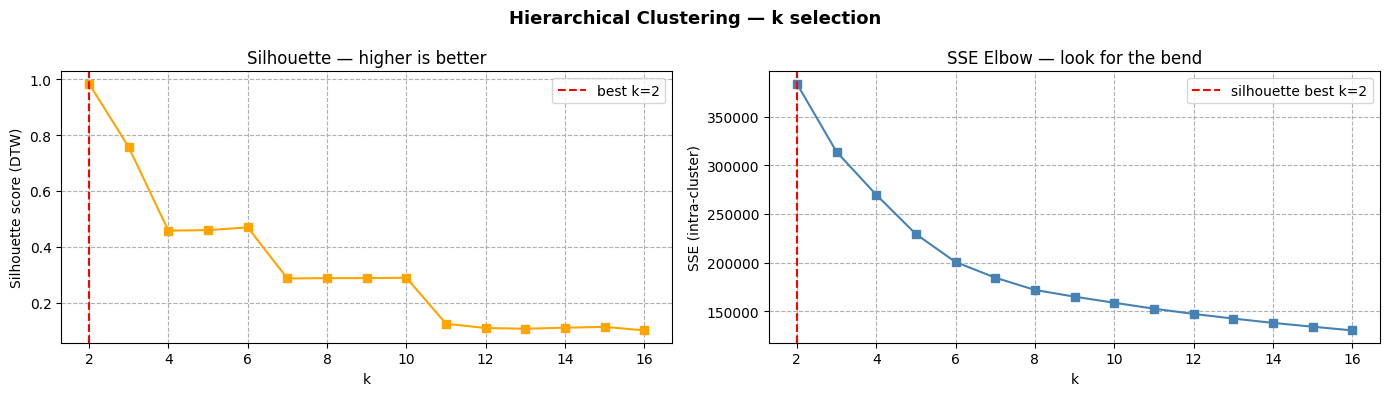

In [ ]:

k_range  = range(2, 17)
sil_list = []
sse_list = []

print("\nSweeping k ...")
for k in k_range:
    labels = fcluster(Z, t=k, criterion="maxclust") - 1  # 0-indexed

    # Silhouette — measures cluster separation
    sil = silhouette_score(dist_mat, labels, metric="precomputed")
    sil_list.append(sil)

    # SSE — sum of squared distances from each point to its cluster centroid
    # Using precomputed dist_mat: for each cluster, sum squared intra-cluster distances
    sse = 0.0
    for c in range(k):
        mask     = np.where(labels == c)[0]
        sub_dist = dist_mat[np.ix_(mask, mask)]
        # Mean distance to cluster center (most central point)
        sse += (sub_dist ** 2).sum() / (2 * len(mask)) if len(mask) > 0 else 0
    sse_list.append(sse)

    print(f"  k={k:2d}  silhouette={sil:.4f}  SSE={sse:.2f}")

# ── Plot both metrics side by side ───────────────────────────────────────────
auto_best_k = list(k_range)[int(np.argmax(sil_list))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Hierarchical Clustering — k selection", fontsize=13, fontweight="bold")

# Silhouette
ax1.plot(list(k_range), sil_list, "s-", color="orange")
#ax1.axvline(auto_best_k, ls="--", color="red", label=f"best k={auto_best_k}")
ax1.set_xlabel("k")
ax1.set_ylabel("Silhouette score (DTW)")
ax1.set_title("Silhouette")
ax1.legend()
ax1.grid(linestyle="--")

# SSE (elbow)
ax2.plot(list(k_range), sse_list, "s-", color="steelblue")
#ax2.axvline(auto_best_k, ls="--", color="red", label=f"silhouette best k={auto_best_k}")
ax2.set_xlabel("k")
ax2.set_ylabel("SSE (intra-cluster)")
ax2.set_title("SSE")
ax2.legend()
ax2.grid(linestyle="--")

plt.tight_layout()
plt.show()

In [18]:
k = 6
cluster_labels = fcluster(Z, k, criterion='maxclust')

# Define 6 distinct colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

## DENDROGRAM


Generating truncated dendrogram with 6 colors...


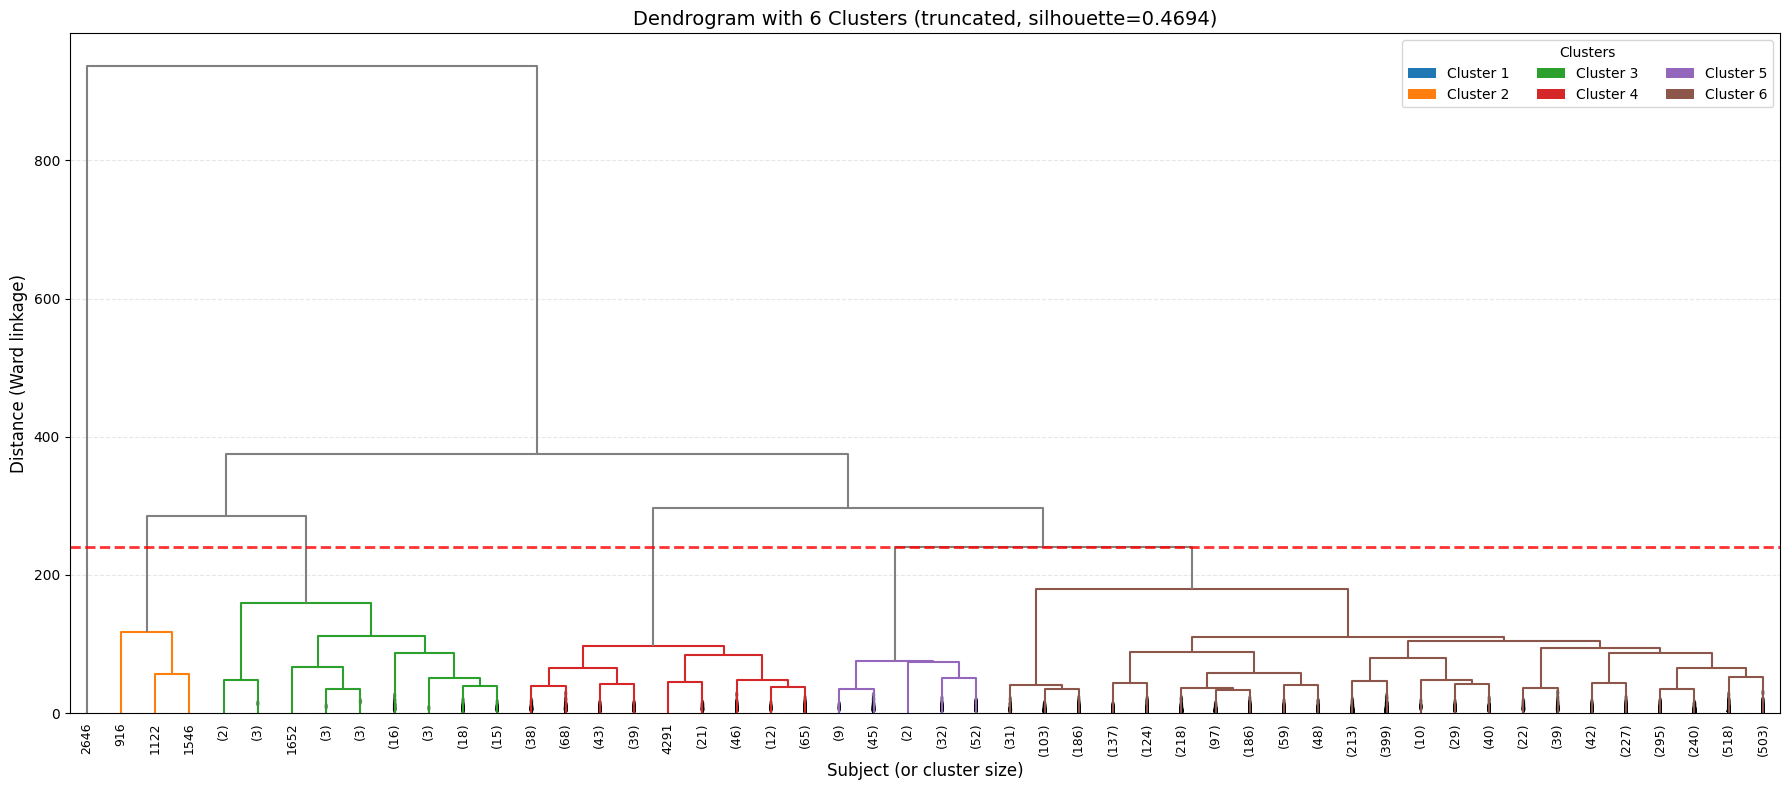

In [20]:
from matplotlib.patches import Patch
print("\nGenerating truncated dendrogram with 6 colors...")

fig, ax = plt.subplots(figsize=(18, 8))

# Get cut height for k=6
cut_height = Z[-(k-1), 2]

# Plot truncated dendrogram
R = dendrogram(
    Z,
    truncate_mode='lastp',
    p=50,  # Show 50 representative leaves
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=cut_height,
    above_threshold_color='gray'
)

# Add cut line
ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=2, alpha=0.8)

# Add colored bar to show cluster distribution
leaf_order = R['leaves']
y_min, y_max = ax.get_ylim()
bar_height = (y_max - y_min) * 0.02
bar_y = y_min - bar_height * 2

# Assign colors to leaves based on cluster membership
# For truncated dendrogram, leaves represent merged clusters
# We'll color by the most frequent cluster in that leaf's range
leaf_colors = []
for i, leaf in enumerate(leaf_order):
    # Simpler: use modulo to cycle through 6 colors for visualization
    leaf_colors.append(colors[i % len(colors)])

# Draw colored bars
for i, color in enumerate(leaf_colors):
    ax.fill_between([i-0.5, i+0.5], bar_y, bar_y + bar_height, 
                    color=color, alpha=0.7)

# Add legend for 6 clusters
legend_elements = [Patch(facecolor=colors[i], label=f'Cluster {i+1}') 
                   for i in range(k)]
ax.legend(handles=legend_elements, loc='upper right', title='Clusters', ncol=3, fontsize=10)

ax.set_xlabel('Subject (or cluster size)', fontsize=12)
ax.set_ylabel('Distance (Ward linkage)', fontsize=12)
ax.set_title(f'Dendrogram with {k} Clusters (truncated, silhouette=0.4694)', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## CLUSTER ANALYSIS

In [21]:
best_k =   6

cluster_labels = fcluster(Z, t=best_k, criterion="maxclust") - 1  # 0-indexed
motifs_df["cluster_hier"] = cluster_labels

In [22]:

print("\n" + "="*50)
print("CLUSTER ANALYSIS")
print("="*50)


cluster_counts = motifs_df["cluster_hier"].value_counts().sort_index()
for c, n in cluster_counts.items():
    print(f"  Cluster {c}: {n:4d} subjects  ({100*n/len(motifs_df):.1f}%)")

print("\n--- Subject indices per cluster (first 10 shown) ---")
for c in range(best_k):
    members = motifs_df.loc[motifs_df["cluster_hier"] == c, "sample_index"].tolist()
    print(f"  Cluster {c} ({len(members)} subjects): "
          f"{members[:10]}{'...' if len(members) > 10 else ''}")

# Centroids: subject closest to the mean DTW distance within each cluster
# (more meaningful than mean window for hierarchical)
print("\n--- Most central subject per cluster ---")
for c in range(best_k):
    mask     = np.where(cluster_labels == c)[0]
    sub_dist = dist_mat[np.ix_(mask, mask)]
    central  = mask[np.argmin(sub_dist.mean(axis=1))]
    print(f"  Cluster {c}: most central subject = sample_index "
          f"{motifs_df.iloc[central]['sample_index']}  "
          f"(avg DTW dist = {sub_dist.mean(axis=1).min():.4f})")

# Motif shape summary per cluster per channel
print("\n--- Centroid motif shape summary (mean ± std across cluster members) ---")
for c in range(best_k):
    mask = cluster_labels == c
    print(f"\n  Cluster {c}  (n={mask.sum()}):")
    for i, ch in enumerate(CHANNELS):
        ch_windows = X_3d[mask, :, i]   # (n_members, W)
        mean_pat   = ch_windows.mean(axis=0)
        print(f"    {ch:>8s}: mean={mean_pat.mean():.4f}  "
              f"std={ch_windows.std():.4f}  "
              f"min={mean_pat.min():.4f}  max={mean_pat.max():.4f}")


CLUSTER ANALYSIS
  Cluster 0:    3 subjects  (0.1%)
  Cluster 1:   64 subjects  (1.5%)
  Cluster 2:  333 subjects  (7.7%)
  Cluster 3:  140 subjects  (3.3%)
  Cluster 4: 3766 subjects  (87.4%)
  Cluster 5:    1 subjects  (0.0%)

--- Subject indices per cluster (first 10 shown) ---
  Cluster 0 (3 subjects): [916, 1122, 1546]
  Cluster 1 (64 subjects): [38, 75, 91, 301, 358, 418, 428, 473, 484, 741]...
  Cluster 2 (333 subjects): [22, 46, 64, 68, 88, 92, 94, 118, 129, 145]...
  Cluster 3 (140 subjects): [24, 98, 148, 150, 215, 246, 254, 289, 290, 338]...
  Cluster 4 (3766 subjects): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
  Cluster 5 (1 subjects): [2646]

--- Most central subject per cluster ---
  Cluster 0: most central subject = sample_index 1546  (avg DTW dist = 48.4529)
  Cluster 1: most central subject = sample_index 418  (avg DTW dist = 18.6272)
  Cluster 2: most central subject = sample_index 1971  (avg DTW dist = 9.3759)
  Cluster 3: most central subject = sample_index 2167  (avg DTW 

In [ ]:
def characterize_clusters(
    motifs_df: pd.DataFrame,
    X_3d: np.ndarray,
    km_final,
    CHANNELS: list,
    best_k: int,
    figsize_per_cluster: tuple = (14, 3),
    save_path: str = None,
):
    """
    Full characterization of clustering results on a motif/time-series dataset.

    Parameters
    ----------
    motifs_df   : DataFrame with columns ['sample_index', 'cluster']
    X_3d        : array of shape (n_subjects, W, n_channels) — raw motif data
    km_final    : fitted KMeans object (must have .cluster_centers_)
    CHANNELS    : list of channel names, length == n_channels
    best_k      : number of clusters
    figsize_per_cluster : (width, height) for each cluster's subplot row
    save_path   : if given, saves the figure to this path
    """

    centroids = km_final.cluster_centers_          # (best_k, W, n_channels)
    W          = X_3d.shape[1]
    n_channels = X_3d.shape[2]
    time_axis  = np.arange(W)

    # ------------------------------------------------------------------ #
    # 1. PRINT — cluster sizes
    # ------------------------------------------------------------------ #
    print("\n" + "=" * 60)
    print("  CLUSTER ANALYSIS")
    print("=" * 60)

    print("\n--- Cluster sizes ---")
    cluster_counts = motifs_df["cluster"].value_counts().sort_index()
    for c, n in cluster_counts.items():
        pct = 100 * n / len(motifs_df)
        print(f"  Cluster {c}: {n:4d} subjects  ({pct:.1f}%)")

    # ------------------------------------------------------------------ #
    # 2. PRINT — per-cluster centroid stats
    # ------------------------------------------------------------------ #
    print("\n--- Centroid summary (mean ± std across time steps, per channel) ---")
    for c in range(best_k):
        print(f"\n  Cluster {c}  ({cluster_counts[c]} subjects):")
        for i, ch in enumerate(CHANNELS):
            vals = centroids[c, :, i]
            print(
                f"    {ch:>10s}:  mean={vals.mean():+.4f}  std={vals.std():.4f}"
                f"  min={vals.min():+.4f}  max={vals.max():+.4f}"
            )

    # ------------------------------------------------------------------ #
    # 3. PRINT — intra-cluster distances & cohesion
    # ------------------------------------------------------------------ #
    print("\n--- Intra-cluster cohesion (Euclidean distance to centroid) ---")

    all_flat   = X_3d.reshape(len(X_3d), -1)          # (n_subjects, W*n_channels)
    cent_flat  = centroids.reshape(best_k, -1)         # (best_k,    W*n_channels)

    intra_stats = {}
    for c in range(best_k):
        members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
        member_data = all_flat[members_idx]             # (n_members, W*n_channels)
        dists       = cdist(member_data, cent_flat[[c]], metric="euclidean").ravel()

        intra_stats[c] = {
            "mean_dist" : dists.mean(),
            "std_dist"  : dists.std(),
            "max_dist"  : dists.max(),
            "min_dist"  : dists.min(),
        }
        print(
            f"  Cluster {c}: mean_dist={dists.mean():.4f}  "
            f"std={dists.std():.4f}  "
            f"min={dists.min():.4f}  max={dists.max():.4f}"
        )

    # ------------------------------------------------------------------ #
    # 4. PRINT — inter-cluster distances (centroid-to-centroid)
    # ------------------------------------------------------------------ #
    print("\n--- Inter-cluster centroid distances ---")
    inter = cdist(cent_flat, cent_flat, metric="euclidean")
    for i in range(best_k):
        for j in range(i + 1, best_k):
            print(f"  Cluster {i} <-> Cluster {j}: {inter[i, j]:.4f}")

    # ------------------------------------------------------------------ #
    # 5. PLOT A — each cluster: one row, one subplot per channel
    #             centroid in bold + all member motifs as faint lines
    # ------------------------------------------------------------------ #
    fig_h = figsize_per_cluster[1] * best_k
    fig, axes = plt.subplots(
        best_k, n_channels,
        figsize=(figsize_per_cluster[0], fig_h),
        sharex=True,
    )
    if best_k == 1:
        axes = axes[np.newaxis, :]   # keep 2-D indexing consistent

    cmap = plt.get_cmap("tab10")

    for c in range(best_k):
        members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
        color       = cmap(c % 10)

        for i, ch in enumerate(CHANNELS):
            ax = axes[c, i]

            # faint member motifs
            for idx in members_idx:
                ax.plot(time_axis, X_3d[idx, :, i],
                        color=color, alpha=0.15, linewidth=0.6)

            # bold centroid
            ax.plot(time_axis, centroids[c, :, i],
                    color=color, linewidth=2.2, label=f"centroid")

            # ± 1 std band across members at each time step
            member_data = X_3d[members_idx, :, i]     # (n_members, W)
            std_band    = member_data.std(axis=0)
            mean_band   = member_data.mean(axis=0)
            ax.fill_between(
                time_axis,
                mean_band - std_band,
                mean_band + std_band,
                color=color, alpha=0.12,
            )

            if c == 0:
                ax.set_title(ch, fontsize=9, fontweight="bold")
            if i == 0:
                ax.set_ylabel(
                    f"Cluster {c}\n(n={len(members_idx)})",
                    fontsize=8, labelpad=4,
                )
            ax.tick_params(labelsize=7)
            ax.grid(True, linewidth=0.3, alpha=0.5)

    fig.suptitle("Centroid motifs per cluster and channel\n(faint = members, bold = centroid, band = ±1 std)",
                 fontsize=11, y=1.01)
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # 6. PLOT B — overlay all centroids on the same axes (one per channel)
    # ------------------------------------------------------------------ #
    fig2, axes2 = plt.subplots(
        1, n_channels,
        figsize=(figsize_per_cluster[0], figsize_per_cluster[1] + 1),
        sharex=True,
    )
    if n_channels == 1:
        axes2 = [axes2]

    for i, ch in enumerate(CHANNELS):
        ax2 = axes2[i]
        for c in range(best_k):
            ax2.plot(
                time_axis, centroids[c, :, i],
                color=cmap(c % 10), linewidth=2,
                label=f"C{c} (n={cluster_counts[c]})",
            )
        ax2.set_title(ch, fontsize=9, fontweight="bold")
        ax2.legend(fontsize=7, loc="upper right")
        ax2.grid(True, linewidth=0.3, alpha=0.5)
        ax2.tick_params(labelsize=7)

    fig2.suptitle("Centroid comparison across clusters (per channel)",
                  fontsize=11)
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # 7. PLOT C — intra-cluster cohesion bar chart
    # ------------------------------------------------------------------ #
    fig3, ax3 = plt.subplots(figsize=(max(5, best_k * 1.5), 4))
    means = [intra_stats[c]["mean_dist"] for c in range(best_k)]
    stds  = [intra_stats[c]["std_dist"]  for c in range(best_k)]
    bars  = ax3.bar(
        range(best_k), means, yerr=stds,
        color=[cmap(c % 10) for c in range(best_k)],
        capsize=5, edgecolor="white", linewidth=0.8,
    )
    ax3.set_xticks(range(best_k))
    ax3.set_xticklabels([f"Cluster {c}" for c in range(best_k)], fontsize=9)
    ax3.set_ylabel("Mean Euclidean distance to centroid", fontsize=9)
    ax3.set_title("Intra-cluster cohesion (lower = tighter cluster)", fontsize=11)
    ax3.grid(axis="y", linewidth=0.3, alpha=0.5)
    for bar, m in zip(bars, means):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + stds[means.index(m)] * 0.05,
                 f"{m:.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path.replace(".png", "_motifs.png"), dpi=150, bbox_inches="tight")
        fig2.savefig(save_path.replace(".png", "_comparison.png"), dpi=150, bbox_inches="tight")
        fig3.savefig(save_path.replace(".png", "_cohesion.png"), dpi=150, bbox_inches="tight")
        print(f"\n✅ Figures saved to {save_path} (3 files)")

    plt.show()
    return intra_stats




In [ ]:
# Calcola centroidi manualmente dall'hierarchical clustering
centroids_hier = np.array([
    X_3d[motifs_df.loc[motifs_df["cluster_hier"] == c, "sample_index"].tolist()].mean(axis=0)
    for c in range(best_k)
])  # shape: (best_k, W, n_channels)

class FakeCentroids:
    def __init__(self, centers):
        self.cluster_centers_ = centers

intra_stats = characterize_clusters(
    motifs_df = motifs_df.rename(columns={"cluster_hier": "cluster"}),
    X_3d      = X_3d,
    km_final  = FakeCentroids(centroids_hier),
    CHANNELS  = CHANNELS,
    best_k    = best_k,
    save_path = "cluster_analysis.png",
)

## PCA + t-SNE

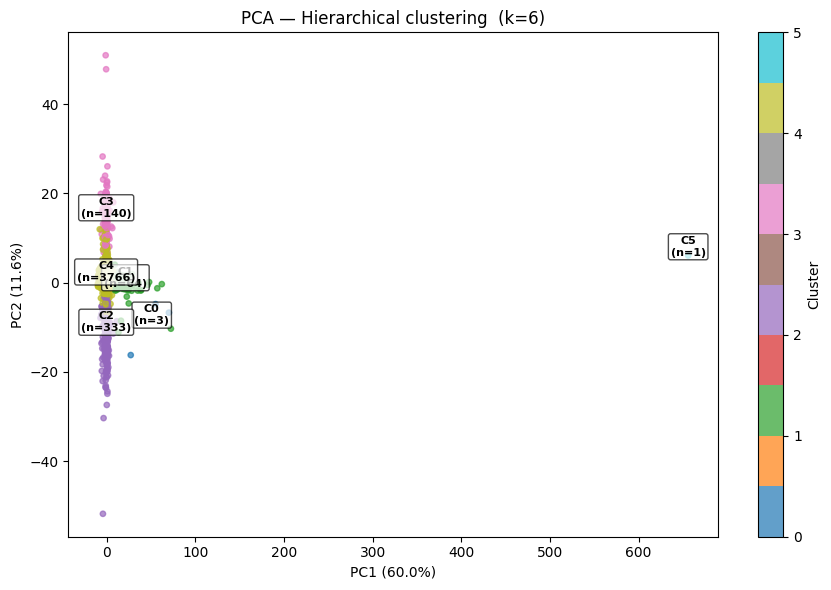

Running t-SNE ...


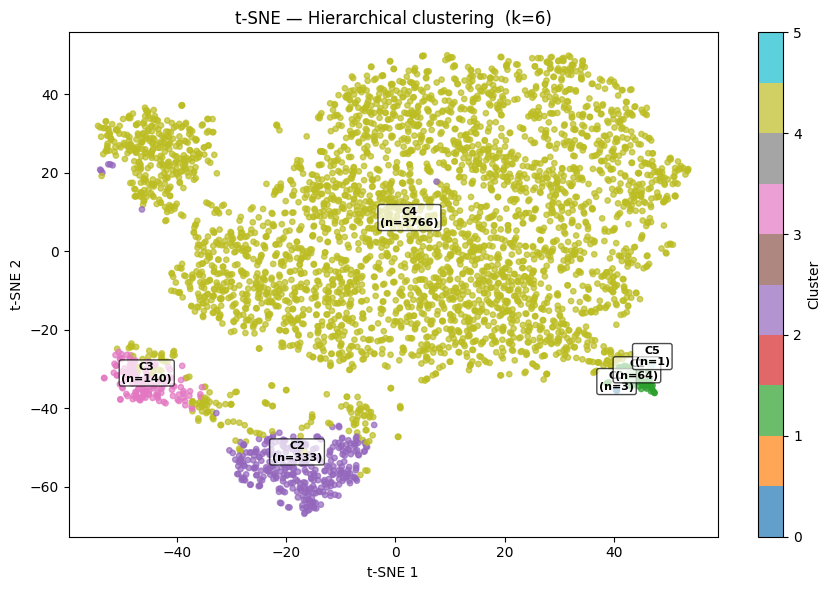

In [23]:
CMAP   = "tab10"
X_flat = X_3d.reshape(len(X_3d), -1)

# — PCA
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=cluster_labels, cmap=CMAP, s=15, alpha=0.7)
for c in range(best_k):
    mask = cluster_labels == c
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax.annotate(f"C{c}\n(n={mask.sum()})", (cx, cy), fontsize=8,
                fontweight="bold", ha="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
ax.set_title(f"PCA — Hierarchical clustering  (k={best_k})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc, ax=ax, label="Cluster")
plt.tight_layout()

plt.show()


# — t-SNE (precomputed DTW distances)
print("Running t-SNE ...")
tsne   = TSNE(n_components=2, perplexity=30, random_state=42,
              metric="precomputed", init="random")
X_tsne = tsne.fit_transform(dist_mat)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=cluster_labels, cmap=CMAP, s=15, alpha=0.7)
for c in range(best_k):
    mask = cluster_labels == c
    cx, cy = X_tsne[mask, 0].mean(), X_tsne[mask, 1].mean()
    ax.annotate(f"C{c}\n(n={mask.sum()})", (cx, cy), fontsize=8,
                fontweight="bold", ha="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
ax.set_title(f"t-SNE — Hierarchical clustering  (k={best_k})")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.colorbar(sc, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()